# Welcome to Learning RL JAX! <a href="https://colab.research.google.com/github/jimma2-del/learning-rl-jax/blob/master/examples/tutorial/tutorial.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" width="140" align="center"/></a>

This tutorial notebook will walk you through general usage of this repository's RL environments and algorithms.

We will explore basic environment rollouts and algorithm training through training an instance of DQN on the `gymnax` library's `Cartpole-v1` environment. Then, we will explore more advanced customization options through training an instace of PPO on the Jumanji library's `Snake-v1` environment.

**A runtime with GPU acceleration is highly recommended**, but not strictly necessary for the basic CartPole example.

## Repository Installation

### If Running Locally

*Note: JAX **does not currently support GPU-acceleration on Windows**. Windows users can use [Windows Subsystem for Linux (WSL)](https://learn.microsoft.com/en-us/windows/wsl/about) if GPU-acceleration is desired (highly recommended).*

We assume you have already cloned the repository. If not, run `git clone https://github.com/jimma2-del/learning-rl-jax.git learning-rl-jax` and navigate to the root directory.

#### Create a virtual environment
If you haven't already, create a [virtual environment](https://docs.python.org/3/library/venv.html) for this repository:
- Create a virtual environment with `python -m venv venv`
- Activate the virtual environment with:
  - Windows: `venv/Scripts/activate`
  - macOS & Linux: `source venv/bin/activate`

Re-open this notebook, now in virtual environment.

#### Install JAX with CUDA 12
Installation details vary for other accelerator devices. See <https://docs.jax.dev/en/latest/installation.html>.

*Note: JAX **does not currently support GPU-acceleration on Windows**. Windows users can use [Windows Subsystem for Linux (WSL)](https://learn.microsoft.com/en-us/windows/wsl/about) if GPU-acceleration is desired (highly recommended).*

In [1]:
#@title Install JAX with CUDA 12, falling back to CPU
import subprocess

try:
    has_gpu = subprocess.run(["nvidia-smi"], capture_output=True).returncode == 0
except:
    has_gpu = False

if has_gpu:
    print("NVIDIA GPU Detected. Installing JAX with CUDA 12.")
    %pip install -U "jax[cuda12]" -q
else:
    print("No NVIDIA GPU detected. Falling back to CPU JAX.")
    %pip install -U "jax[cpu]" -q

NVIDIA GPU Detected. Installing JAX with CUDA 12.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.4/174.4 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.5/85.5 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 40.2 MB/s eta 0:00:00


In [2]:
#@title Verify JAX installation devices
import jax

devices = jax.devices()

if not any(d.platform == 'gpu' for d in devices):
    print("GPU JAX not available. Falling back to CPU.")
    print("A runtime with GPU acceleration is highly recommended.")

print("Available Devices:", devices)
print("Using Backend:", jax.default_backend())

Available Devices: [CudaDevice(id=0)]
Using Backend: gpu


### If Running on Google Colab

**Switch to a GPU runtime:** Top-left menu, "Runtime > Change runtime type".

Clone the repository from GitHub and navigate to the tutorial directory.

In [ ]:
#@title Clone repository
!git clone https://github.com/jimma2-del/learning-rl-jax.git learning-rl-jax

Cloning into 'learning-rl-jax'...
remote: Enumerating objects: 1442, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 1442 (delta 0), reused 2 (delta 0), pack-reused 1436 (from 2)
Receiving objects: 100% (1442/1442), 110.87 MiB | 66.12 MiB/s, done.
Resolving deltas: 100% (866/866), done.


In [ ]:
#@title Navigate CWD to the tutorial directory
%cd learning-rl-jax/examples/tutorial
%pwd

/content/learning-rl-jax/examples/tutorial


'/content/learning-rl-jax/examples/tutorial'

### Install Packages (Both Local & Colab)

These steps may vary depending on the current working directory (CWD) of the current Jupyter notebook session. We assume that the CWD is `/examples/tutorial` for the commands below. You may have to edit paths or navigate with `%cd <PATH>` if your CWD is different.

In [ ]:
%pwd
# should end in `/examples/tutorial`

'/content/learning-rl-jax/examples/tutorial'

Install this repository as a package. This will also install all other base dependencies.

In [ ]:
#@title Install main dependencies
%pip install -e ../../. -q
    # replace '../../.' with the path to the root directory of the repository

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.0/101.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 456.9/456.9 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 944.3/944.3 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 181.6 MB/s eta 0:00:00
  Building editable for learning-rl-jax (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.1 which is incompatible.


Install RL Environment Libraries: [`gymnax`](https://github.com/RobertTLange/gymnax/tree/main) and [Jumanji](https://github.com/instadeepai/jumanji/tree/main)

In [ ]:
#@title Install `gymnax`
%pip install -e ../../.[gymnax] -q
    # replace '../../.' with the path to the root directory of the repository

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.7/721.7 kB 14.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Building editable for learning-rl-jax (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


In [ ]:
#@title Install Jumanji
%pip install -e ../../.[jumanji] -q
    # replace '../../.' with the path to the root directory of the repository

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 7.5 MB/s eta 0:00:00
  Building editable for learning-rl-jax (pyproject.toml) ... done


**Restart the notebook session.**

(Google Colab) Top-left menu, "Runtime > Restart session".

In [ ]:
#@title (Google Colab) Nagivate CWD back to the tutorial directory
%cd learning-rl-jax/examples/tutorial
%pwd

/content/learning-rl-jax/examples/tutorial


'/content/learning-rl-jax/examples/tutorial'

## Basics

### Environment API
This repository has its own environment API. However, there are wrappers for many common libraries, eg. `gymnax`.

In [ ]:
#@title Main Imports
import jax
import jax.numpy as jnp

from core.envs.gymnax import GymnaxWrapper
import gymnax

#### Environment Basics

In [ ]:
#@title Make gymnax environment and wrap
gymnax_env, gymnax_env_params = gymnax.make("CartPole-v1")
env = GymnaxWrapper(gymnax_env, gymnax_env_params)

Every environment has an *action space* and an *observation space*.

In this repository, a `Space` is simply an object containing two arbitrary *PyTrees*, defining the *upper and lower bounds* of the space. Spaces store *static* information, so leaves are *numpy* arrays rather than JAX arrays.

Leaves of *integer dtype* are assumed to represent *discrete* features, while leaves of *float dtype* are assumed to represent *continuous features*. Continuous features can be marked as *unbounded* on either side by setting `low=-np.inf` or `high=np.inf` &mdash; approximately &plusmn;3.4028235e+38.

In [ ]:
print("Observation Space:", env.observation_space)
print("Action Space:", env.action_space)

Observation Space: Space(low=array([-4.8000002e+00, -3.4028235e+38, -4.1887903e-01, -3.4028235e+38],
      dtype=float32), high=array([4.8000002e+00, 3.4028235e+38, 4.1887903e-01, 3.4028235e+38],
      dtype=float32))
Action Space: Space(low=array(0, dtype=int32), high=array(1, dtype=int32))


Now, let's do a rollout.

We initialize states with `env.reset(key)`, get an observation with `env.get_obs(key, state)`, and step the environment with `env.step(key, state, action)`. Methods are not JITed by default, so we wrap them with `jax.jit()` manually (it is actually better to wrap the entire rollout with `jax.jit` rather than individual functions &mdash; more on this later).

We can get a random action using `env.action_space.sample(key)`.

In [ ]:
key = jax.random.key(0)

key, reset_key = jax.random.split(key, 2)
state, info = jax.jit(env.reset)(reset_key)

states = [ state ]
rewards = [ 0 ]

terminated = False
truncated = False

while not (terminated or truncated):
    key, obs_key, act_key, step_key = jax.random.split(key, 4)

    # the 'state' is different from the 'observation'
    # agents typically use the 'observation' rather than the underlying state
    # here, we don't do anything with the observation other than just printing it out
    obs = jax.jit(env.get_obs)(obs_key, state)

    # Sample a random action
    action = env.action_space.sample(act_key)

    state, reward, terminated, truncated, info = jax.jit(env.step)(step_key, state, action)
    states.append(state)
    rewards.append(reward)

    print(f"Obs: {obs}; Action: {action}; Reward: {reward};")

print(f"Total Steps: {len(rewards) - 1}; Total Return: {sum(rewards)};")

Obs: [-0.04927062 -0.04791088  0.00814265 -0.0138162 ]; Action: 0; Reward: 1.0;
Obs: [-0.05022884 -0.24314865  0.00786633  0.2814246 ]; Action: 0; Reward: 1.0;
Obs: [-0.05509181 -0.4383819   0.01349482  0.5765781 ]; Action: 0; Reward: 1.0;
Obs: [-0.06385945 -0.63369036  0.02502638  0.8734815 ]; Action: 0; Reward: 1.0;
Obs: [-0.07653326 -0.82914346  0.04249601  1.1739264 ]; Action: 0; Reward: 1.0;
Obs: [-0.09311613 -1.0247911   0.06597453  1.4796231 ]; Action: 0; Reward: 1.0;
Obs: [-0.11361195 -1.2206534   0.095567    1.7921598 ]; Action: 1; Reward: 1.0;
Obs: [-0.13802502 -1.0267239   0.13141018  1.5306469 ]; Action: 0; Reward: 1.0;
Obs: [-0.15855949 -1.2231625   0.16202313  1.8612878 ]; Action: 0; Reward: 1.0;
Obs: [-0.18302274 -1.4196483   0.19924888  2.199583  ]; Action: 0; Reward: 1.0;
Total Steps: 10; Total Return: 10.0;


Let's visualize the rollout.

<small>*NOTE: The visualizer is broken in the main branch of `gymnax` for gym environments. This repository uses an [unmerged PR](https://github.com/RobertTLange/gymnax/pull/84) which fixes it.*</small>

In [ ]:
#@title `gymnax` visualization imports
import matplotlib.pyplot as plt
from gymnax.visualize import Visualizer

# Code for displaying images on Jupyter notebooks
from IPython.display import display, Image, clear_output
def jupyter_show_image(path):
    clear_output(wait=True)
    with open(path, 'rb') as f:
        display(Image(data=f.read()))

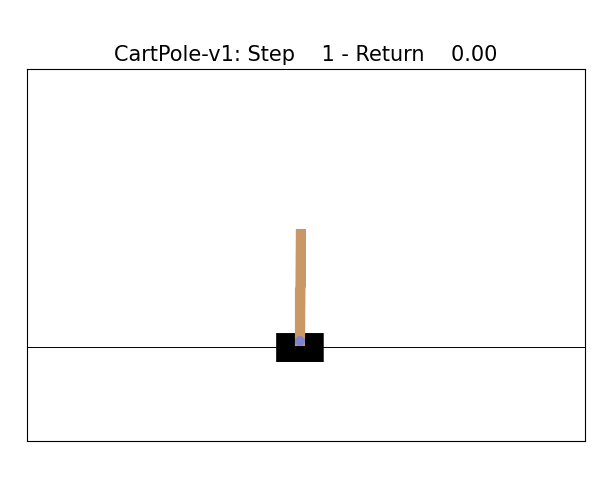

In [ ]:
#@title Save and show visualization gif
cum_rewards = jnp.cumsum(jnp.array(rewards))
states = jax.device_get(states) # transfer from device (GPU) to host (CPU) for faster processing
vis = Visualizer(gymnax_env, gymnax_env_params, states, cum_rewards)
vis.animate(save_fname='cartpole.gif')

plt.close()
jupyter_show_image('cartpole.gif')

#### Environment Utilities
In practice, it is often not necessary to interact with the environment directly as this repository provides many utility functions which satisfy most purposes.

Let's do the same rollout as before, but this time using the `rollout_episode()` utility.

In addition to convenience, this function also provides a performance increase. The function groups the rollout into large chunks of fully JIT compiled code, minimizing JAX's high Python dispatch overhead.

In [ ]:
from flax import nnx
from core.envs.utils import rollout_episode, RandomActor

In [ ]:
rngs = nnx.Rngs(0, env=1, actions=2)
timesteps, final_timestep = rollout_episode(rngs, env, RandomActor(env.action_space))

eps_steps = len(timesteps.reward)
eps_return = sum(timesteps.reward)
print(f"{'Truncated' if timesteps.truncated[-1] else 'Terminated'} at steps={eps_steps}, return={eps_return}.")

Terminated at steps=14, return=14.0.


Utilities like `rollout_episode` often take an *`Actor`* &mdash; a callable which takes an observation (and optionally, a `flax.nnx.Rngs` object for randomness), and returns an action and an info dictionary. Here, we used `RandomActor`, an actor which simply samples random actions.

Note that to support Flax NNX networks in actors, we have switched to using a `flax.nnx.Rngs` object for random number generation. This also allows us to set separate keys for environment steps and actor actions.

Let's visualize the new rollout:

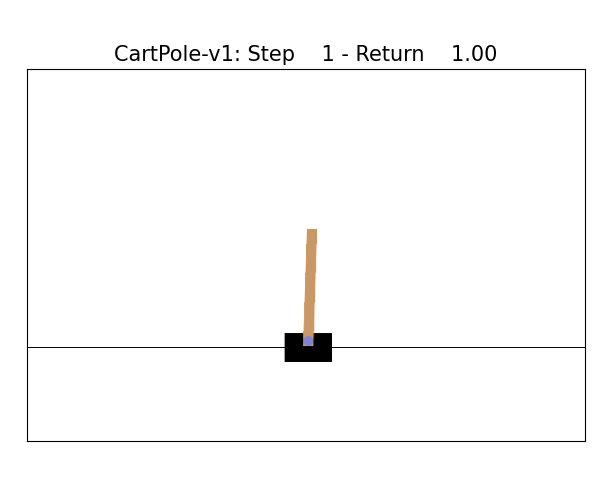

In [ ]:
# Transpose the PyTree of state arrays into a list of individual states
states = jax.device_get(timesteps.state) # transfer from device (GPU) to host (CPU) for faster processing
states = [ jax.tree.map(lambda x: x[i], states) for i in range(eps_steps) ]

cum_rewards = jnp.cumsum(timesteps.reward)

vis = Visualizer(gymnax_env, gymnax_env_params, states, cum_rewards)
vis.animate(save_fname='cartpole2.gif')

plt.close()
jupyter_show_image('cartpole2.gif')

### RL Algorithm API
The API is not fully standardized between different algorithms as of now. However, usage tends to follow a common pattern.

#### Training
Let's train a DQN agent for our `CartPole-v1` environment.

In [ ]:
#@title Imports for training
from optax import schedules

from core.algos import dqn
from core.envs.wrappers import VmapWrapper

We configure hyperparameters in a dataclass.

Here, we manually set values for most of the parameters to showcase the full range of settings. However, every parameter has a default value, meaning that any parameter can be omitted.

In [ ]:
#@title Set up hyperparameters
STEPS = 100_000 # total training steps

hyperparameters = dqn.Hyperparameters(
    n_envs = 8, # number of environments to run in parallel, to fully saturate GPU
        # using a very low number here for the sake of making this example accessible
        # GPU-acceleration allows us to run many more envs in parallel
            # -- at least 256; upwards of 8192 for powerful setups

    discount_rate = 0.99,

    learning_rate = 2.5e-4,
    max_grad_norm = 10.0,

    train_freq = 4, # number of env steps per network update
        # since train_freq < n_envs, we repeatedly:
            # take 1 step in each parallel env, giving us 8 total samples,
            # do 8 / 4 = 2 optimize steps at once

    batch_size = 32,

    epsilon = schedules.linear_schedule(1, 0.05, 0.1*STEPS),
        # the majority of float parameters can take a Schedule instead of a constant value
        # a Schedule is simply any function which takes in a step count and returns a value

    replay_buffer_size = 100_000,

    truncated_frac = 1.0/500, # fraction of timesteps expected to be truncated
        # to handle truncations properly, we need the observation after the truncation to bootstrap Q values
        # we allocate extra space for these observations in the replay buffer depending on `truncated_frac`
        # lowering `truncated_frac` saves memory by allocating less space for these observations
        # however, truncated timesteps exceeding this limit will be treated as terminated

    #target_update_interval = 5000, # interval for hard target updates
    polyak_tau = 0.005, # use polyak averaging instead of hard target updates

    double_dqn = False # double DQN add-on
)

rngs = nnx.Rngs(0, env=1, actions=2, params=3, optimize_samples=4)

Let's initialize a starting training state, and train.

In [ ]:
#@title Initialize algorithm
# environments used in algorithms need to be able to handle batches of parallel states
# this wrapper parallelizes the env using jax.vmap()
vmapped_env = VmapWrapper(env)

algo = dqn.DQN(vmapped_env, hyperparameters)

# mark train function to be JIT compiled (does not actually compile until actually called)
train = nnx.jit(algo.train, static_argnames=('steps',), donate_argnames=('training_state'))
    # `donate_argnames=('training_state')` saves memory by allowing training_state to be overritten

In [ ]:
#@title Train
# the TrainingState holds environment, network, optimizer, and replay buffer states
# intialize the training states, using the default network architectures
training_state = algo.init_training_state(rngs, prefill_steps=5000)

training_state, metrics = train(rngs, training_state, STEPS)

In [ ]:
#@title Log metrics
# chunk metrics into N_LOGS groups for easier viewing
N_LOGS = 10
avg_metrics = { key: list(map(jnp.mean, jnp.array_split(val, N_LOGS))) for key, val in metrics.items() }

# print metrics
steps = avg_metrics.pop('steps')
for i in range(N_LOGS):
    print(f"Step {steps[i]:.0f}: " + " ".join([ f"{key}={val[i]:.5g}" for key, val in avg_metrics.items() ]))

Step 5004: q_loss=0.51734
Step 15004: q_loss=1.1342
Step 25004: q_loss=2.6973
Step 35004: q_loss=4.9147
Step 45004: q_loss=6.7622
Step 55004: q_loss=8.5318
Step 65004: q_loss=9.146
Step 75004: q_loss=9.6718
Step 85004: q_loss=9.7008
Step 95004: q_loss=8.2925


#### Evaluation/Visualization
Let's evaluate and visualize the trained agent.

In [ ]:
from core.envs.utils import evaluate_episodes, rollout_episode

We first make an `Actor` using the trained networks:

In [ ]:
# make an Actor (obs, rngs -> action, info) using the trained networks
actor = algo.make_actor(training_state.networks, epsilon=0)
    # disable epsilon greedy exploration using epsilon=0 (default)

This allows us to easily perform evaluation/rollouts using the prebuilt environment utils:

In [ ]:
#@title Evaluate trained agent
EVAL_EPS = 8

evaluate = nnx.jit(evaluate_episodes, static_argnames=('env', 'episodes', 'n_envs'))
returns, lengths = evaluate(rngs, vmapped_env, actor, episodes=EVAL_EPS, n_envs=EVAL_EPS)

print(f"Episode Return: mean={jnp.mean(returns)} std={jnp.std(returns, ddof=1)}")
print(f"Episode Length: mean={jnp.mean(lengths)} std={jnp.std(lengths, ddof=1)}")

Episode Return: mean=500.0 std=0.0
Episode Length: mean=500.0 std=0.0


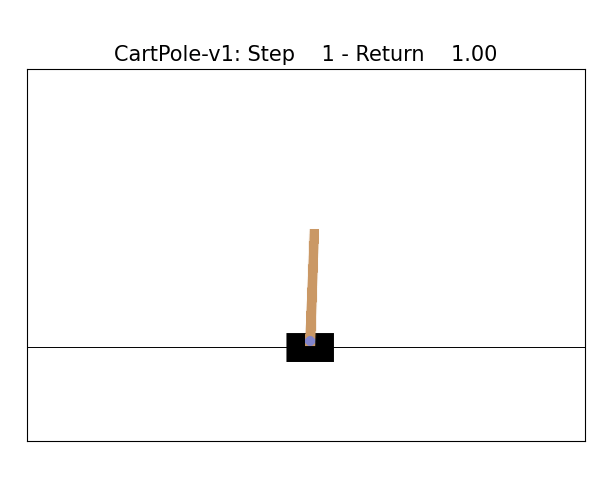

In [ ]:
#@title Visualize trained actor
rngs = nnx.Rngs(0, env=10, actions=20)
timesteps, final_timestep = rollout_episode(rngs, env, actor)

eps_steps = len(timesteps.reward)
eps_return = sum(timesteps.reward)
print(f"{'Truncated' if timesteps.truncated[-1] else 'Terminated'} at steps={eps_steps}, return={eps_return}.")

# Transpose the PyTree of state arrays into a list of individual states
states = jax.device_get(timesteps.state) # transfer from device (GPU) to host (CPU) for faster processing
states = [ jax.tree.map(lambda x: x[i], states) for i in range(eps_steps) ]

cum_rewards = jnp.cumsum(timesteps.reward)

vis = Visualizer(gymnax_env, gymnax_env_params, states, cum_rewards)
vis.animate(save_fname='cartpole_dqn.gif')

plt.close()
jupyter_show_image('cartpole_dqn.gif')

#### Saving/Loading
We can save/load training states using [Orbax](https://github.com/google/orbax).

In [ ]:
import os
import orbax.checkpoint as ocp

In [ ]:
#@title Make temporary directory to store checkpoints
os.makedirs(os.path.abspath('./_tmp'), exist_ok=True)

In [ ]:
SAVE_PATH = os.path.abspath('./_tmp/cartpole_dqn_checkpoint')
SAVE_PATH

'/content/learning-rl-jax/examples/tutorial/_tmp/cartpole_dqn_checkpoint'

In [ ]:
#@title Save training state
state = nnx.state(training_state)
checkpointer_save = ocp.StandardCheckpointer()
checkpointer_save.save(SAVE_PATH, state)

In [ ]:
#@title Load training state
# evaluate the shape to load without actually performing any FLOPs (expensive)
graphdef, abstract_state = nnx.eval_shape(lambda: nnx.split(algo.init_training_state(nnx.Rngs(0))))

checkpointer_load = ocp.StandardCheckpointer()
loaded_state = checkpointer_load.restore(SAVE_PATH, abstract_state)

loaded_training_state = nnx.merge(graphdef, loaded_state)

In [ ]:
# data has been restored:
loaded_training_state.steps

# we can now continue training

Array(100000, dtype=int32)

If further training is not necessary, we can also only save the actor:

In [ ]:
ACTOR_SAVE_PATH = os.path.abspath('./_tmp/cartpole_dqn_actor')
ACTOR_SAVE_PATH

'/content/learning-rl-jax/examples/tutorial/_tmp/cartpole_dqn_actor'

In [ ]:
#@title Save actor only
state = nnx.state(algo.make_actor(training_state.networks))
checkpointer_save = ocp.StandardCheckpointer()
checkpointer_save.save(ACTOR_SAVE_PATH, state)

In [ ]:
#@title Load actor
# evaluate the shape to load without actually performing any FLOPs (expensive)
graphdef, abstract_state = nnx.eval_shape(lambda: nnx.split(algo.make_actor(rngs=nnx.Rngs(0))))

checkpointer_load = ocp.StandardCheckpointer()
loaded_state = checkpointer_load.restore(ACTOR_SAVE_PATH, abstract_state)

loaded_actor = nnx.merge(graphdef, loaded_state)

In [ ]:
#@title Evaluate loaded actor
EVAL_EPS = 8

evaluate = nnx.jit(evaluate_episodes, static_argnames=('env', 'episodes', 'n_envs'))
returns, lengths = evaluate(rngs, vmapped_env, loaded_actor, episodes=EVAL_EPS, n_envs=EVAL_EPS)

print(f"Episode Return: mean={jnp.mean(returns)} std={jnp.std(returns, ddof=1)}")
print(f"Episode Length: mean={jnp.mean(lengths)} std={jnp.std(lengths, ddof=1)}")

Episode Return: mean=500.0 std=0.0
Episode Length: mean=500.0 std=0.0


## Further Customization
Let's explore how to further customize environments/agents through training a PPO agent for the Jumanji `Snake-v1` environment.

### Setup

In [ ]:
#@title Imports for PPO/Jumanji Snake-v1
import time

import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

from flax import nnx
from optax import schedules

from core.algos import ppo

from core.envs.wrappers import VmapWrapper
from core.envs.utils import evaluate_episodes, rollout_episode

from core.envs.jumanji import JumanjiWrapper
import jumanji

# -----

# Hack to allow jumanji to run locally
import sys, types
if "google.colab" not in sys.modules:
    sys.modules["google.colab"] = types.ModuleType("google.colab")

# Code for displaying images on Jupyter notebooks
from IPython.display import display, Image, clear_output
def jupyter_show_image(path):
    clear_output(wait=True)
    with open(path, 'rb') as f:
        display(Image(data=f.read()))

In [ ]:
#@title Make env
jumanji_env = jumanji.make('Snake-v1')
env = JumanjiWrapper(jumanji_env)

In [ ]:
#@title Set up hyperparameters
STEPS = 10_000_000 # total training steps

hyperparameters = ppo.Hyperparameters(
    n_envs = 256,

    learning_rate = 2.5e-4,

    discount_rate = 0.99,
    gae_lambda = 0.95,

    rollout_length = 32,
    n_minibatches = 32,
    n_epochs = 8,

    clip_epsilon = 0.2,

    vf_coef = 0.5,
    ent_coef = 0.01,

    normalize_advantages = True,

    recompute_advantages = True,
    target_kl = 0.02,

    truncated_frac = 1/1000,
)

rngs = nnx.Rngs(0, env=1, actions=2, params=3, optimize_samples=4)

In [ ]:
#@title Initialize algorithm and set up training functions
algo = ppo.PPO(VmapWrapper(env), hyperparameters)

EVAL_EPS = 256
EVAL_INTERVAL = 1_000_000
N_LOGS_PER_EVAL = 3

def train_loop(rngs, algo, training_state, eval_env):
    train = nnx.jit(algo.train, static_argnames=('steps',), donate_argnames=('training_state'))

    @nnx.jit
    def evaluate(rngs, actor):
        return evaluate_episodes(
            rngs, eval_env, actor,
            EVAL_EPS, EVAL_EPS
        )

    while training_state.steps < STEPS:
        print()

        start_time = time.perf_counter()
        training_state, metrics = train(rngs, training_state, EVAL_INTERVAL)
        elasped_time = time.perf_counter() - start_time

        # NOTE: Elapsed time will be significantly higher during the first two iterations due to JIT compile time.
            # Steps/sec will greatly increase for the remaining iterations.

        # Log metrics
        avg_metrics = jax.tree.map(lambda x: list(map(jnp.mean, jnp.array_split(x, N_LOGS_PER_EVAL))), metrics)
        steps = avg_metrics.pop('steps')
        for i in range(N_LOGS_PER_EVAL):
            print(f"Step {steps[i]:.0f}: " + " ".join([ f"{key}={val[i]:.5g}" for key, val in avg_metrics.items() ]))

        print()

        sps = EVAL_INTERVAL / elasped_time
        print(f"COMPLETED steps={training_state.steps}; sps={sps:,.1f}")

        # Evaluate
        actor = algo.make_actor(training_state.networks, deterministic_sampling=True)
            # deterministic_sampling=True -> use action distribution means; no randomness
        returns, lengths = evaluate(rngs, actor)

        print(f"Episode Return: mean={jnp.mean(returns)} std={jnp.std(returns, ddof=1)}")
        print(f"Episode Length: mean={jnp.mean(lengths)} std={jnp.std(lengths, ddof=1)}")

    return training_state

We can train the agent as-is and it will *work*:

In [ ]:
#@title Run training (uncomment)
# training_state = algo.init_training_state(rngs)
# training_state = train_loop(rngs, algo, training_state, VmapWrapper(env))


Step 172032: approx_kl=0.015852 clip_frac=0.22087 entropy=0.26263 n_epochs_done=5.9268 policy_loss=-0.024622 value_loss=0.032923
Step 507904: approx_kl=0.015263 clip_frac=0.17274 entropy=0.20051 n_epochs_done=4.0732 policy_loss=-0.017942 value_loss=0.016748
Step 843776: approx_kl=0.015353 clip_frac=0.14076 entropy=0.14102 n_epochs_done=2.7805 policy_loss=-0.012823 value_loss=0.058334

COMPLETED steps=1007616; sps=55,010.4
Episode Return: mean=4.296875 std=4.2553019523620605
Episode Length: mean=2804.1640625 std=1635.3740234375

Step 1179648: approx_kl=0.015552 clip_frac=0.1209 entropy=0.11859 n_epochs_done=2.878 policy_loss=-0.0092342 value_loss=0.034813
Step 1515520: approx_kl=0.014855 clip_frac=0.10386 entropy=0.10185 n_epochs_done=3.0976 policy_loss=-0.010883 value_loss=0.027118
Step 1851392: approx_kl=0.014679 clip_frac=0.10733 entropy=0.10987 n_epochs_done=2.9268 policy_loss=-0.010305 value_loss=0.041061

COMPLETED steps=2015232; sps=63,003.0
Episode Return: mean=4.6953125 std=4.

However, we can definitely improve performance from here!

### Environment Wrappers
Environment wrappers are a flexible tool, allowing you to customize observations, rewards, transition dynamics, etc. This repository contains many built-in wrappers for common use cases &mdash; normalizing actions, caching reset states, JIT compiling environment methods, etc. &mdash; but it can also be useful to create your own custom wrapper for more precise control.

In [ ]:
#@title Wrapper imports
import chex

from jumanji.environments.routing.snake import Observation as SnakeObs, State as SnakeState

from core.envs.base import Environment, Space
from core.envs.wrappers import Wrapper, EpisodeStepCountWrapper

Currently, the agent spends a lot of time doing nothing: surviving, but not collecting any apples. Let's fix this with a custom environment wrapper!

Specifically, let's add a small negative reward on each step. This penalizes wasting time and encouraging more efficient pathing towards apples. To ensure that the agent doesn't simply *kill itself* to avoid recieving these penalties, let's also add a penalty for dying.

In [ ]:
class CustomSnakeWrapper(Wrapper[SnakeState, SnakeObs, jax.Array, jax.Array]):
    def __init__(self,
        env: Environment[SnakeState, SnakeObs, jax.Array, jax.Array],
        step_penalty: float = -0.01,
        death_penalty: float = -1.0,
    ) -> None:
        super().__init__(env)

        self.step_penalty = step_penalty
        self.death_penalty = death_penalty

    # Override the step method to add custom functionality
    def step(self, key: chex.PRNGKey, state: SnakeState, action: jax.Array) \
            -> tuple[SnakeState, jax.Array, jax.Array, jax.Array, dict]:
        state, reward, terminated, truncated, info = super().step(key, state, action)

        # apply custom penalties
        reward += self.step_penalty
        reward += terminated * self.death_penalty

        return state, reward, terminated, truncated, info

    # Other methods will keep default behavior

Wrappers have the same API as environments. By default, methods and properties will do nothing extra, directly calling the corresponding method on the internal, unwrapped env (which can be accessed as `self.env`). To add custom behavior, you only need to override the specific methods/properties you want to alter.

Let's wrap the `env` with our custom wrapper:

In [ ]:
train_env = CustomSnakeWrapper(env,
    step_penalty = -0.01,
    death_penalty = -1.0,
)

eval_env = env # keep original env for evaluation

Additionally, let's use a built-in wrapper from this repository to *truncate* episodes that have gone on for too long.

Jumanji's `Snake-v1` environment has a built-in `steps_limit` option, but it *terminates* episodes upon reaching the limit. To keep the environment Markovian, it must pass the episode step count in the observation, adding complexity.

We can simplify this by *truncating* episodes instead, allowing us to avoid passing the step count. See <https://gymnasium.farama.org/tutorials/gymnasium_basics/handling_time_limits/> for more details.

In [ ]:
MAX_EPS_LEN = 3000
train_env = EpisodeStepCountWrapper(train_env, max_eps_len=MAX_EPS_LEN, terminate=False)
eval_env = EpisodeStepCountWrapper(eval_env, max_eps_len=MAX_EPS_LEN, terminate=False)

### Custom Network Architecture + Action Masking
RL algorithm networks in this repository are highly customizable. You can easily edit basic hyperparameters &mdash; hidden dimensions, activation function, layer norm, etc. &mdash; or make your own custom networks classes for more specific behaviors.

#### Network Basics

All networks in this repository are made up of a shared trunk which processes observations, followed by one or more output heads. If an action input is necessary, eg. for Q networks in TD3 & SAC, it is passed directly to the Q output heads as a secondary argument.

Ie, for SAC:
```
                ┌──────────────┐        ┌─────────────┐
observation ───>│ Shared Trunk │────┬──>│ Policy Head │────> action distribution
                └──────────────┘    │   └─────────────┘
                                    │   ┌────────┐
                                    └──>│ Q Head │────> q value(s)
                           action ─────>│   (x2) │
                                        └────────┘
```
Or, programmatically,
```py
trunk_output = networks.obs_trunk(obs)

action_distribution = networks.policy_head(trunk_output)
q1 = networks.q_heads[0](trunk_output, action)
q2 = networks.q_heads[1](trunk_output, action)
```

For simple customization, we can use the `Networks` class's `make_default_<NETWORK TYPE>()` methods.

Returning to the PPO example, we can do

In [ ]:
obs_trunk = ppo.Networks.make_default_obs_trunk(
    observation_space = env.observation_space,

    normalize_observations = True, # True is the default
    obs_clip_threshold = 5 # clip observations beyond 5 stds from the mean
)

policy_head = ppo.Networks.make_default_policy_head(rngs,
    input_dim = env.observation_space.flattened_dim, # must match obs_trunk output

    action_space = env.action_space,
    do_state_independent_stds = False, # for continuous actions

    hidden_dims = (512, 256, 128), # customize hidden layer architecture
    do_layer_norm = False, # disable layer norm
    activation_func = nnx.swish, # change the activation function
)

value_head = ppo.Networks.make_default_value_head(rngs,
    input_dim = env.observation_space.flattened_dim, # must match obs_trunk output

    hidden_dims = (512, 256, 128), # customize hidden layer architecture
    do_layer_norm = False, # disable layer norm
    activation_func = nnx.swish, # change the activation function
)

# Gather trunk and heads into a Networks object
custom_networks = ppo.Networks(obs_trunk, policy_head, value_head)


To use our custom networks in the algorithm, pass it when making the training state:

In [ ]:
training_state = algo.init_training_state(rngs, networks=custom_networks)

It should be noted that if you do *not* wish to share any network layers between the actor and critic networks, simply *keep the default!* By default, the shared `obs_trunk` doesn't actually have any learnable parameters, only handling observation pre-processing.

The default `obs_trunk` consists only of a normalization by running mean/std transform, plus a flatten transform:

<small>*`Pipe` simply applys a sequence of callables one after the other. It is essentially a simplier version of `nnx.Sequential`.*</small>

In [ ]:
%psource ppo.Networks.make_default_obs_trunk

    @staticmethod
    def make_default_obs_trunk(
        observation_space: Space[TEnvObs],
        normalize_observations: bool = True, 
        obs_running_mean_var: RunningMeanVar[TEnvObs] | None = None, 
        obs_clip_threshold: float | None = None
    ) -> Callable[[TEnvObs], TTrunkOut]:
        layers = []

        if normalize_observations:
            inp = observation_space.shapes_dtypes if obs_running_mean_var is None else obs_running_mean_var
            layers.append(RunningMeanVarNorm(inp, clip_threshold=obs_clip_threshold))

        layers.append(observation_space.flatten)

        return Pipe(*layers)


The default policy and value heads each consist of fully connected layers according to the specified `hidden_dims`, followed by an output linear layer. For policy heads, the output is then reshaped to match the shape of the action distribution. Logits for discrete actions are kept raw, and standard deviations for continuous actions are kept as log standard deviations. For value heads, a simple squeeze is done to convert the result into a single scalar value.

In [ ]:
%psource ppo.Networks.make_default_policy_head

    @staticmethod
    def make_default_policy_head(
        rngs: nnx.Rngs, input_dim: int, action_space: Space[ArrayLike], do_state_independent_stds: bool = True,
        hidden_dims: Sequence[int] = (128, 128), do_layer_norm: bool = True, activation_func=nnx.tanh
    ) -> Callable[[TTrunkOut], TEnvAction]:
        head = ActionDistributionHead(action_space, do_state_independent_stds)

        mlp = MLP(
            rngs, (input_dim, *hidden_dims, head.input_dim), 
            do_layer_norm=do_layer_norm, activation_func=activation_func
        )

        return Pipe(mlp, head)


In [ ]:
%psource ppo.Networks.make_default_value_head

    @staticmethod
    def make_default_value_head(
        rngs: nnx.Rngs, input_dim: int,
        hidden_dims: Sequence[int] = (256, 256), do_layer_norm: bool = True, activation_func=nnx.tanh
    ) -> Callable[[TTrunkOut], jax.Array]:
        return Pipe(
            MLP(
                rngs, (input_dim, *hidden_dims, 1), 
                do_layer_norm=do_layer_norm, activation_func=activation_func
            ),
            lambda x: jnp.squeeze(x, axis=-1)
        )


#### Custom Network Objects
For further customization, we can make our own trunk and output head objects from scratch.

In [ ]:
#@title Imports for custom network objects
from core.utils.nnx_modules import ActionDistributionHead

To take advantage of the 2D spatial structure of observations in Snake, let's define a CNN for `obs_trunk`.

Jumanji's `Snake-v1` environment also includes an action mask with the observations, so let's also pass it along for use in invalid action masking in the policy head.

In [ ]:
class SnakeCNN(nnx.Module):
    def __init__(self, rngs: nnx.Rngs) -> None:
        self.conv1 = nnx.Conv(5, 32, kernel_size=(3, 3), rngs=rngs) # (12, 12, 5) -> (12, 12, 32)
        self.conv2 = nnx.Conv(32, 64, kernel_size=(3, 3), strides=2, rngs=rngs) # (12, 12, 32) -> (6, 6, 64)
        self.linear = nnx.Linear(6 * 6 * 64, 256, rngs=rngs)
        self.layer_norm = nnx.LayerNorm(256, rngs=rngs)

    def __call__(self, x: SnakeObs, rngs: nnx.Rngs | None = None) -> tuple[jax.Array, jax.Array]:
        features = x.grid # 'grid' contains the actual observation features

        features = nnx.relu(self.conv1(features))
        features = nnx.relu(self.conv2(features))
        features = features.reshape(*features.shape[:-3], -1)  # flatten
        features = nnx.relu(self.layer_norm(self.linear(features)))

        return features, x.action_mask # pass the action mask down as well for use in the policy head

obs_trunk = SnakeCNN(rngs)

Now, let's define a custom policy head, which takes the extracted features and action mask from the trunk, and outputs a distribution over actions.

We use the action mask here by setting the logits of invalid actions to `-jnp.inf`, ensuring that they are never taken.

In [ ]:
class SnakePolicyHead(nnx.Module):
    def __init__(self, rngs: nnx.Rngs) -> None:
        self.action_distribution_head = ActionDistributionHead(env.action_space)
            # this class unflattens actions into a distribution,
                # and contains learnable log std params for continuous actions
            # not really necessary for a simple discrete action space; included for illustrative purposes

        self.linear = nnx.Linear(256, self.action_distribution_head.input_dim, rngs=rngs)

    def __call__(self, x: tuple[jax.Array, jax.Array], rngs: nnx.Rngs | None = None) -> jax.Array:
        features, action_mask = x

        features = self.linear(features)
        action_dist = self.action_distribution_head(features) # unflatten into an action distribution
            # does nothing here since unflattening is not necessary; included for illustrative purposes

        # apply invalid action masking, setting invalid action logits to -jnp.inf
        action_dist = jnp.where(action_mask, action_dist, -jnp.inf)

        # in Jumanji Snake-v1, there can be no valid actions for certain states,
            # which leads to NaNs as ALL logits are masked to -jnp.inf
        no_valid_actions = jnp.all(jnp.logical_not(action_mask), axis=-1, keepdims=True)
        action_dist = jnp.where(no_valid_actions, 0, action_dist)
            # lets replace the distribution with a uniform distribution in these cases

        return action_dist

policy_head = SnakePolicyHead(rngs)

The value head is *almost* unchanged from the default, except we have to add an extra step at the front to discard the action mask.

In [ ]:
value_head = nnx.Sequential(
    lambda x: x[0], # discard x[1] -> the action mask
    ppo.Networks.make_default_value_head(rngs, 256, hidden_dims=(256,))
)

Finally, lets assemble everything into a `ppo.Networks` object.

In [ ]:
custom_networks = ppo.Networks(obs_trunk, policy_head, value_head)

### Custom Optimizer
We can also edit optimizer hyperparameters, or use a different optimizer entirely.

By default, all RL algorithms in this repository use an AdamW optimizer (though weight decay is set to 0.0 by default), with a global-norm-based gradient clipping transform added to to the front.

For convenience, the learning rate and maximum gradient norm (for clipping) hyperparameters are located directly in the `Hyperparameters` dataclass. We can set them as follows:

In [ ]:
hyperparameters = hyperparameters.replace(
    learning_rate = schedules.linear_schedule(3e-4, 1e-4, STEPS),
    max_grad_norm = None # disables gradient clipping
)

We can set other optimizer parameters using the `optimizer_params` field, a dictionary. You can leave out any of the parameters, and it will take the default value. Like almost every other float parameter, optimizer parameters can also be schedules.

In [ ]:
hyperparameters = hyperparameters.replace(optimizer_params = {
    'weight_decay': 1e-5,
    'b1': 0.9,
    # ...
})

The AdamW optimizer works well, but for the sake of the example, let's switch to RMSprop.

First, we need to fix the `optimizer_params` field. Lets also re-enable gradient clipping.

In [ ]:
hyperparameters = hyperparameters.replace(
    max_grad_norm = 0.5,
    optimizer_params = { 'decay': 0.9 }
)

Now, let's make our RMSprop optimizer.

This repository uses a custom schedule updating system as the default system in `optax` is based off of *gradient* steps, not *environment* steps. To facilitate this feature, we must make a optimizer factory function and wrap it with `optax.inject_hyperparams`.

This factory function should have named arguments corresponding to every desired optimizer parameter. In particular, a `learning_rate` parameter is always necessary, and a `max_grad_norm` parameter is necessary if `hyperparameters.max_grad_norm` is not set to `None`. The remaining named parameters should correspond to parameters set in the `hyperparameters.optimizer_params` dictionary.

In [ ]:
import optax

# define optimizer factory function, wrapping with optax.inject_hyperparams
@optax.inject_hyperparams
def make_custom_optimizer(learning_rate, max_grad_norm, decay=0.9):
    return optax.chain(
        optax.clip_by_global_norm(max_grad_norm),
        optax.rmsprop(learning_rate, decay)
    )

# get starting values (steps=0) for all optimizer parameters
algo = ppo.PPO(VmapWrapper(train_env), hyperparameters)
optimizer_params = algo.resolve_optimizer_params(steps=0)
    # convenience function to get a dictionary of values for all optimizer parameters at a particular step
    # includes learning_rate and max_grad_norm, taking them from the root hyperparameters dataclass

# make the optimizer, initialized with the starting values
custom_optimizer = make_custom_optimizer(**optimizer_params)

Like with custom networks, we pass the custom optimizer when making the training state to use it in an algorithm:

In [ ]:
training_state = algo.init_training_state(rngs, networks=custom_networks, optax_optimizer=custom_optimizer)

### Putting it all together

To summarize, we have:
- Added environment wrappers to alter rewards, punishing doing nothing, and truncate episodes beyond a certain length.
- Customized the networks to use a shared CNN feature extractor and apply invalid action masking in the policy head.
- Replaced the optimizer with a custom instance of RMSprop, and set custom optimizer parameters.

Let's train!

<small>If you have the compute, you can train for much longer, reaching near optimal performance by 200M-300M steps.</small>

In [ ]:
algo = ppo.PPO(VmapWrapper(train_env), hyperparameters)
training_state = algo.init_training_state(rngs, networks=custom_networks, optax_optimizer=custom_optimizer)
training_state = train_loop(rngs, algo, training_state, VmapWrapper(eval_env))


Step 172032: approx_kl=0.019573 clip_frac=0.22803 entropy=0.19251 n_epochs_done=2.3659 policy_loss=-0.010683 value_loss=0.098465
Step 507904: approx_kl=0.01736 clip_frac=0.15519 entropy=0.10432 n_epochs_done=2.9268 policy_loss=-0.013998 value_loss=0.18078
Step 843776: approx_kl=0.016693 clip_frac=0.13687 entropy=0.086687 n_epochs_done=3.5122 policy_loss=-0.012859 value_loss=0.21809

COMPLETED steps=1007616; sps=41,703.7
Episode Return: mean=23.8828125 std=7.68815803527832
Episode Length: mean=383.9765625 std=563.7286376953125

Step 1179648: approx_kl=0.016579 clip_frac=0.1246 entropy=0.076313 n_epochs_done=3.7317 policy_loss=-0.011841 value_loss=0.22774
Step 1515520: approx_kl=0.016447 clip_frac=0.11956 entropy=0.072672 n_epochs_done=3.6341 policy_loss=-0.01019 value_loss=0.23693
Step 1851392: approx_kl=0.01613 clip_frac=0.11839 entropy=0.071195 n_epochs_done=4.1951 policy_loss=-0.01186 value_loss=0.22423

COMPLETED steps=2015232; sps=35,440.0
Episode Return: mean=26.3203125 std=9.065

Let's visualize the trained agent:

In [ ]:
#@title Rollout trained actor
actor = algo.make_actor(training_state.networks, deterministic_sampling=True)

rngs = nnx.Rngs(0, env=100, actions=200)
timesteps, final_timestep = rollout_episode(rngs, eval_env, actor)

eps_steps = len(timesteps.reward)
eps_return = sum(timesteps.reward)
print(f"{'Truncated' if timesteps.truncated[-1] else 'Terminated'} at steps={eps_steps}, return={eps_return}.")

Terminated at steps=1045, return=67.0.


In [ ]:
#@title Make gif animation
VISUALIZE_FPS = 10 #@param {type:"slider", min:1, max:30, step:1}
VISUALIZE_FRAME_SKIP = 1 #@param {type:"slider", min:1, max:10, step:1}
    # skip frames to speed up rendering time

states = timesteps.state.state # need to unwrap state due to EpisodeStepCountWrapper

# Transpose the PyTree of state arrays into a list of individual states
states = jax.device_get(states) # transfer from device (GPU) to host (CPU) for faster processing
states = [ jax.tree.map(lambda x: x[i], states) for i in range(0, eps_steps, VISUALIZE_FRAME_SKIP) ]

print("Animating... -- this can take a few minutes")
delay_ms = 1/VISUALIZE_FPS * VISUALIZE_FRAME_SKIP
jumanji_env.animate(states, delay_ms, 'snake_custom_ppo.gif')

plt.close()
jupyter_show_image('snake_custom_ppo.gif')

![Snake Custom PPO](snake_custom_ppo.gif)